In [1]:
# doublet removal 

In [1]:
import os
import numpy as np
import doubletdetection
import scanpy as sc
import tarfile
import matplotlib
matplotlib.use('PDF')
import matplotlib.pyplot as plt
import sys
import pandas as pd
import seaborn as sns
import anndata as ad

ModuleNotFoundError: No module named 'doubletdetection'

In [2]:
adata_list = sc.read_h5ad("filtered_postQC_postcb_combined_adata_14dpi.h5ad")

In [3]:
clf = doubletdetection.BoostClassifier(
    n_iters=10,
    clustering_algorithm="louvain",
    standard_scaling=True,
    pseudocount=0.1,
    n_jobs=-1)

In [4]:
unique_sample_ids = adata_list.obs['Sample'].cat.categories
unique_sample_ids

Index(['5', '64', '35', '101', '4', '3', '66', '102', '33'], dtype='object')

In [5]:
# Process each sample in adata_list
for sample_id in unique_sample_ids:
    # Subset the data for the current sample_id
    subset_condition = adata_list.obs['Sample'] == sample_id
    adata_subset = adata_list[subset_condition].copy()

    if adata_subset.shape[0] == 0:
        print(f"Empty data subset for sample {sample_id}, skipping...")
        continue

    try:
        # Perform doublet detection and remove doublets
        doublets = clf.fit(adata_subset.X).predict(p_thresh=1e-3, voter_thresh=0.5)
        doublet_score = clf.doublet_score()
        adata_subset.obs["doublet"] = doublets
        adata_subset.obs["doublet_score"] = doublet_score
        adata_subset.uns['doublets_removed'] = adata_subset.obs.doublet.sum()

        # Remove doublets
        adata_subset_filtered = adata_subset[adata_subset.obs.doublet == 0].copy()

        # Define the output path for h5ad file
        output_h5ad_path = f"/work/abg/mkapoor/Project_Fang_10X/14dpi_PRRSV/Project_Fang_10X/Project_Fang_10X/{sample_id}_filtered.h5ad"

        # Save the filtered data in h5ad format
        adata_subset_filtered.write_h5ad(output_h5ad_path)

        print(f"Processed sample {sample_id}: removed {adata_subset.uns['doublets_removed']} doublets")

    except Exception as e:
        print(f"Error processing sample {sample_id}: {e}")


  0%|          | 0/10 [00:00<?, ?it/s]

Processed sample 5: removed 517.0 doublets


  0%|          | 0/10 [00:00<?, ?it/s]

Processed sample 64: removed 483.0 doublets


  0%|          | 0/10 [00:00<?, ?it/s]

...

Processed sample 66: removed 450.0 doublets


  0%|          | 0/10 [00:00<?, ?it/s]

Processed sample 102: removed 855.0 doublets


  0%|          | 0/10 [00:00<?, ?it/s]

Processed sample 33: removed 638.0 doublets


In [6]:
directory_path = "/work/abg/mkapoor/Project_Fang_10X/14dpi_PRRSV/Project_Fang_10X/Project_Fang_10X/"
db_output = os.listdir(directory_path)
print(db_output)  # Print to verify the files

# Initialize an empty list to hold the AnnData objects
adata_list = []

for file in db_output:
    if file.endswith('_filtered.h5ad'):  # Ensure only .h5ad files are read
        file_path = os.path.join(directory_path, file)  # Create the full file path
        adata = sc.read_h5ad(file_path)  # Read the .h5ad file
        adata_list.append(adata)  # Append to the list
        print(f"Successfully loaded {file}")

['66_filtered.h5ad', 'cellranger_Script.sh', 'doublet_detection_14dpi.ipynb', 'Sample_5', 'filtered_postQC_postcb_postdoublet_combined_adata_14dpi.h5ad', 'convergence_test.pdf', 'Sample_64', '5_filtered.h5ad', '33_filtered.h5ad', 'Sample_35', '64_filtered.h5ad', 'filtered_postQC_combined_adata_14dpi.h5ad', 'cellranger_script2.sh', '102_filtered.h5ad', 'filtered_postQC_postcb_combined_adata_14dpi.h5ad', 's-5240623-count.out', 'Sample_101', 'Untitled.ipynb', 'Sample_4', 'Untitled1.ipynb', 'Sample_3', '.ipynb_checkpoints', 'cellbender_10k_python.py', 'Sample_66', '4_filtered.h5ad', 'ckpt.tar.gz', 'rename_fang.sh', '35_filtered.h5ad', 'Sample_102', 'threshold_test.pdf', 's-5342689-cellbender_10k.out', '3_filtered.h5ad', 'list_files.txt', 'Sample_33', 'cellbender_10k_script.sh', 's-5243008-count.out', '101_filtered.h5ad']
Successfully loaded 66_filtered.h5ad
Successfully loaded 5_filtered.h5ad
Successfully loaded 33_filtered.h5ad
Successfully loaded 64_filtered.h5ad
Successfully loaded 102_

In [7]:
combined_adata = ad.concat(adata_list, join='outer')

In [8]:
combined_adata

AnnData object with n_obs × n_vars = 51792 × 25880
    obs: 'Sample', 'Timepoint', 'Treatment', 'Sex', 'Sow', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'PassViability', 'PassGenesDet', 'PassLibSize', 'PassAll', 'doublet', 'doublet_score'

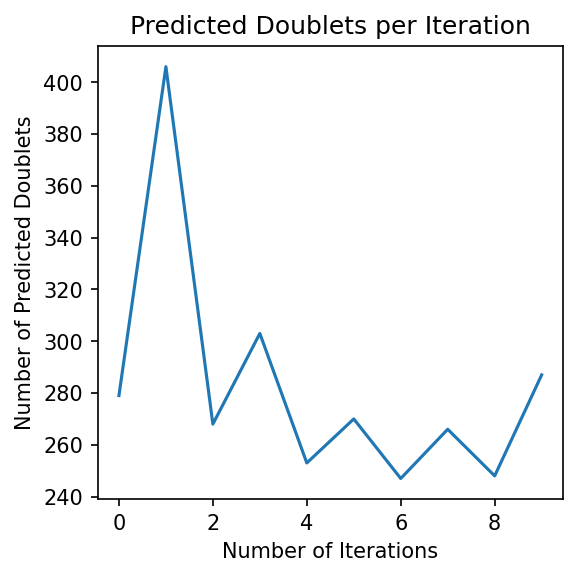

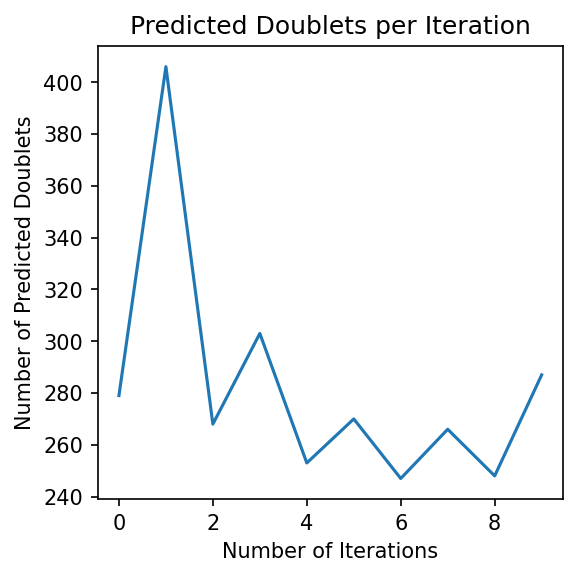

In [9]:
%matplotlib inline
doubletdetection.plot.convergence(clf, save=('convergence_test.pdf'), show=False, p_thresh=1e-16, voter_thresh=0.5)